1. DATA OVERVIEW
Shape: (31112, 16)

Columns: ['geological_era', 'weather_pattern', 'region', 'aptitude_score', 'performance_score', 'stability_index', 'personal_interest', 'load_ratio', 'brew_preference', 'instrument', 'species', 'index_weight', 'mineral_type', 'activity_duration', 'composite_rank', 'label']

2. EDA

Missing values per column:
 geological_era       2
weather_pattern      3
region               4
aptitude_score       4
performance_score    2
stability_index      2
personal_interest    6
load_ratio           2
brew_preference      7
instrument           3
species              3
index_weight         3
mineral_type         3
activity_duration    2
composite_rank       1
label                3
dtype: int64

Total missing: 50

Duplicate rows: 0

Label distribution (raw):
 label
no     23645
yes     7464
NaN        3
Name: count, dtype: int64

Categorical columns and their cardinality:
  geological_era: 5 unique
  weather_pattern: 7 unique
  region: 21 unique
  personal_inte

<ipython-input-1-4a08376aa088>:257: MatplotlibDeprecationWarning: The x parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(x) instead.
  plt.savefig("confusion_matrices.png", dpi=150)
<ipython-input-1-4a08376aa088>:257: MatplotlibDeprecationWarning: The y parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(y) instead.
  plt.savefig("confusion_matrices.png", dpi=150)


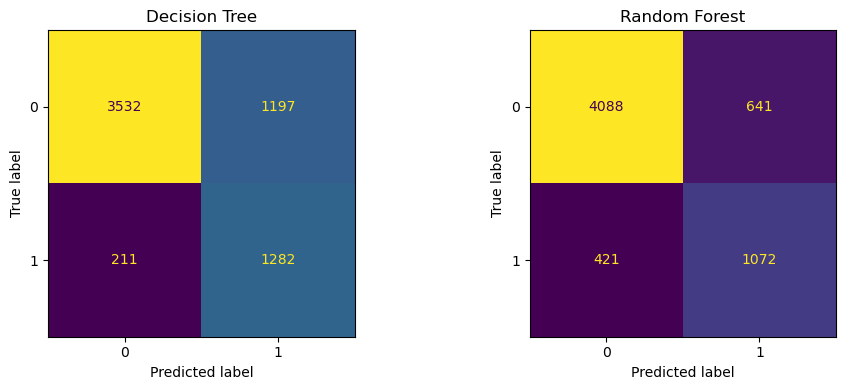

<ipython-input-1-4a08376aa088>:266: MatplotlibDeprecationWarning: The x parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(x) instead.
  plt.savefig("roc_curves.png", dpi=150)
<ipython-input-1-4a08376aa088>:266: MatplotlibDeprecationWarning: The y parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(y) instead.
  plt.savefig("roc_curves.png", dpi=150)


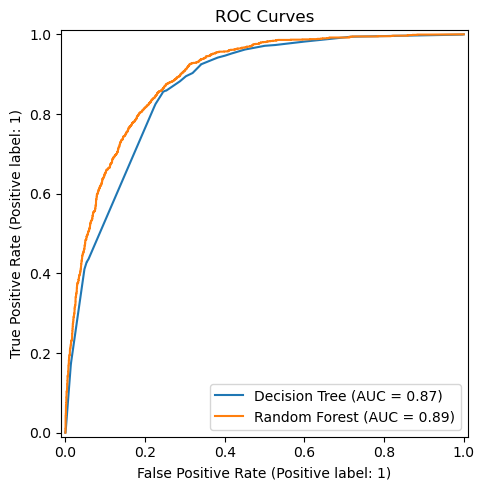


Top 15 feature importances (Random Forest):
weather_pattern_Monsoon        0.113690
composite_rank                 0.113566
aptitude_score                 0.100015
stability_index                0.078238
performance_score              0.073865
activity_duration              0.069001
instrument_Cello               0.066603
load_ratio                     0.055239
index_weight                   0.045779
weather_pattern_Heatwave       0.033375
instrument_Zither              0.017748
instrument_Oboe                0.016150
personal_interest_Astronomy    0.014816
personal_interest_Falconry     0.014484
brew_preference_Latte          0.014009
dtype: float64


<ipython-input-1-4a08376aa088>:287: MatplotlibDeprecationWarning: The x parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(x) instead.
  plt.savefig("feature_importance.png", dpi=150)
<ipython-input-1-4a08376aa088>:287: MatplotlibDeprecationWarning: The y parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(y) instead.
  plt.savefig("feature_importance.png", dpi=150)


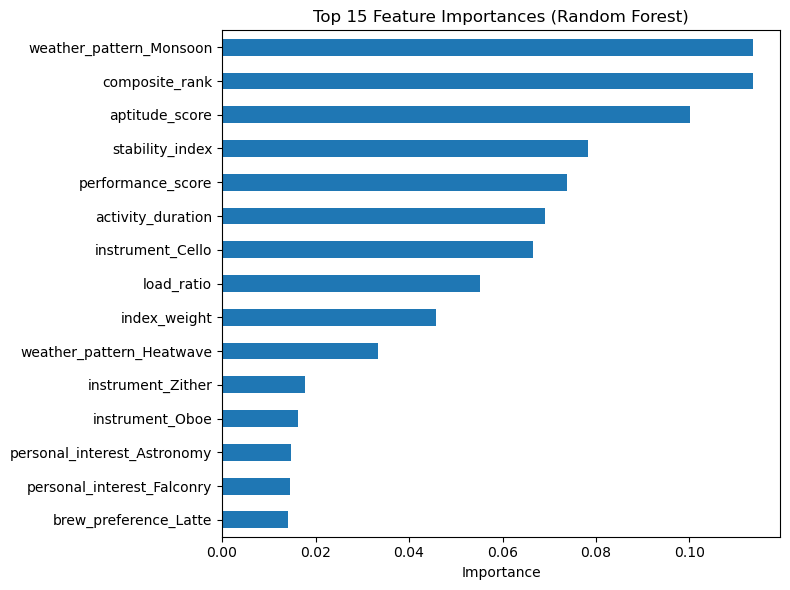


SUMMARY

Decision Tree best params: {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
Random Forest best params: {'clf__class_weight': 'balanced', 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__n_estimators': 100}

Final comparison:
         Model  Accuracy  Precision  Recall     F1  ROC-AUC
Decision Tree    0.7737     0.5171  0.8587 0.6455   0.8689
Random Forest    0.8293     0.6258  0.7180 0.6687   0.8919


In [1]:

# IN6227 Assignment 1 - Variant 1
# Decision Tree vs Random Forest
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# used to replication results
RANDOM_STATE = 0

# 1. Load data
df = pd.read_csv("train.csv")

print("=" * 60)
print("1. DATA OVERVIEW")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# 2. Exploratory Data Analysis
print("\n" + "=" * 60)
print("2. EDA")

print("\nMissing values per column:\n", df.isnull().sum())
print("\nTotal missing:", df.isnull().sum().sum())
print("\nDuplicate rows:", df.duplicated().sum())

print("\nLabel distribution (raw):\n", df["label"].value_counts(dropna=False))

# print("\nNumeric summary:\n", df.describe())

cat_cols_all = df.select_dtypes(include=["object", "str"]).columns.tolist()
print("\nCategorical columns and their cardinality:")
for c in cat_cols_all:
    print(f"  {c}: {df[c].nunique()} unique")

# 3. Data Cleaning
print("\n" + "=" * 60)
print("3. DATA CLEANING")

# 3.1 Drop rows where label is missing (cannot train on them)
before = len(df)
df = df.dropna(subset=["label"])
print(f"Dropped {before - len(df)} rows with missing label. Remaining: {len(df)}")

# 3.2 Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows. Remaining: {len(df)}")

# 3.3 Identify numeric and categorical columns (excluding label)
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "str"]).columns.tolist()
cat_cols.remove("label")

print("\nNumeric columns:", num_cols)
print("Categorical columns:", cat_cols)

# 3.4 Impute missing values
# Numeric -> median, Categorical -> mode
for c in num_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].median())

for c in cat_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].mode()[0])

print("\nMissing values after imputation:", df.isnull().sum().sum())

# 4. Feature Engineering
print("\n" + "=" * 60)
print("4. FEATURE ENGINEERING")

# Encode label: yes -> 1, no -> 0
df["label"] = df["label"].map({"no": 0, "yes": 1})
print("Label distribution after encoding:\n", df["label"].value_counts())

X = df.drop(columns=["label"])
y = df["label"]

# One-hot encoding for categorical features
# Tree models do NOT need scaling of numeric features
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"   # numeric columns passed through unchanged
)

# 5. Train & Test 
print("\n" + "=" * 60)
print("5. TRAIN/TEST")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Train label balance:\n", y_train.value_counts(normalize=True))
print("Test label balance:\n", y_test.value_counts(normalize=True))

# 6. Decision Tree
print("\n" + "=" * 60)
print("6. DECISION TREE")

dt_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

dt_param_grid = {
    "clf__criterion": ["gini", "entropy"],
    "clf__max_depth": [None, 5, 10, 20, 30],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 5],
    "clf__class_weight": [None, "balanced"]
}

dt_grid = GridSearchCV(
    dt_pipe,
    dt_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)
dt_grid.fit(X_train, y_train)

print("\nBest DT params:", dt_grid.best_params_)
print("Best DT CV F1:", round(dt_grid.best_score_, 4))

dt_best = dt_grid.best_estimator_

# Train set performance (for overfitting check)
y_train_pred_dt = dt_best.predict(X_train)
y_train_prob_dt = dt_best.predict_proba(X_train)[:, 1]

# Test set performance
y_pred_dt = dt_best.predict(X_test)
y_prob_dt = dt_best.predict_proba(X_test)[:, 1]

print("\n--- Decision Tree: Train ---")
print("Accuracy:", round(accuracy_score(y_train, y_train_pred_dt), 4))
print("F1      :", round(f1_score(y_train, y_train_pred_dt), 4))

print("\n--- Decision Tree: Test ---")
print(classification_report(y_test, y_pred_dt, digits=4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_dt), 4))

# 7. Random Forest
print("\n" + "=" * 60)
print("7. RANDOM FOREST")

rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

# full version, takes hours to run
# rf_param_grid = {
#     "clf__n_estimators": [100, 200, 300],
#     "clf__max_depth": [None, 10, 20, 30],
#     "clf__min_samples_leaf": [1, 2, 5],
#     "clf__max_features": ["sqrt", "log2"],
#     "clf__class_weight": [None, "balanced"]
# }

# easy version, takes 20 minus to run
rf_param_grid = {
    "clf__n_estimators": [100],
    "clf__max_depth": [None, 10],
    "clf__min_samples_leaf": [1, 2],
    "clf__max_features": ["sqrt"],
    "clf__class_weight": [None, "balanced"]
}

rf_grid = GridSearchCV(
    rf_pipe,
    rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

print("\nBest RF params:", rf_grid.best_params_)
print("Best RF CV F1:", round(rf_grid.best_score_, 4))

rf_best = rf_grid.best_estimator_

y_train_pred_rf = rf_best.predict(X_train)
y_train_prob_rf = rf_best.predict_proba(X_train)[:, 1]

y_pred_rf = rf_best.predict(X_test)
y_prob_rf = rf_best.predict_proba(X_test)[:, 1]

print("\n--- Random Forest: Train ---")
print("Accuracy:", round(accuracy_score(y_train, y_train_pred_rf), 4))
print("F1      :", round(f1_score(y_train, y_train_pred_rf), 4))

print("\n--- Random Forest: Test ---")
print(classification_report(y_test, y_pred_rf, digits=4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))

# 8. Evaluation & Comparison
print("\n" + "=" * 60)
print("8. MODEL COMPARISON")

def evaluate(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall": round(recall_score(y_true, y_pred), 4),
        "F1": round(f1_score(y_true, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_true, y_prob), 4),
    }

results = pd.DataFrame([
    evaluate("Decision Tree", y_test, y_pred_dt, y_prob_dt),
    evaluate("Random Forest", y_test, y_pred_rf, y_prob_rf),
])
print("\nTest set comparison:\n", results.to_string(index=False))

# Save comparison table
results.to_csv("model_comparison.csv", index=False)

# 9. Graphs
print("\n" + "=" * 60)
print("9. Graphs")

# 9.1 Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, ax=axes[0], colorbar=False)
axes[0].set_title("Decision Tree")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

# 9.2 ROC curves
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_dt, name="Decision Tree", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="Random Forest", ax=ax)
ax.set_title("ROC Curves")
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

# 9.3 Random Forest feature importance
# Get feature names after one-hot encoding
ohe = rf_best.named_steps["prep"].named_transformers_["cat"]
ohe_feature_names = ohe.get_feature_names_out(cat_cols)
all_feature_names = list(ohe_feature_names) + num_cols

importances = rf_best.named_steps["clf"].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

print("\nTop 15 feature importances (Random Forest):")
print(feat_imp.head(15))

plt.figure(figsize=(8, 6))
feat_imp.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

# Summary
print("\n" + "=" * 60)
print("SUMMARY")
print("\nDecision Tree best params:", dt_grid.best_params_)
print("Random Forest best params:", rf_grid.best_params_)
print("\nFinal comparison:\n", results.to_string(index=False))